<a href="https://colab.research.google.com/github/farhanjutt2099-coder/AI_Disease_Prediction_System/blob/main/Disease_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DISEASE PREDICTION SYSTEM - PIMA INDIANS DIABETES DATASET

# 1. IMPORT LIBRARIES

In [ ]:
# 1. IMPORT LIBRARIES

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import joblib
import os

# 2. DATA COLLECTION

In [ ]:
# Dataset Path
# Replace this with the direct link to your dataset file if it's hosted online,
# or upload the 'diabetes.csv' file to your Colab environment.
DATA_PATH = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv" # Example direct link

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)

DATASET LOADED SUCCESSFULLY


# 3. EXPLORATORY DATA ANALYSIS (EDA)



1. DATASET OVERVIEW

Shape of Dataset:
(768, 9)

Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


2. MISSING VALUE ANALYSIS

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Missing Values After Conversion:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinTh

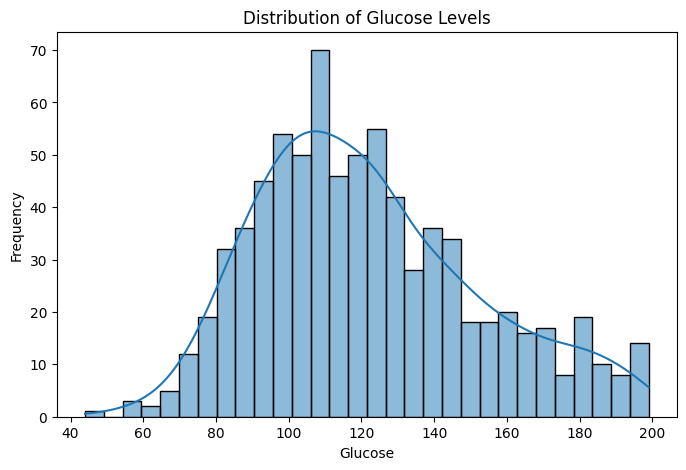

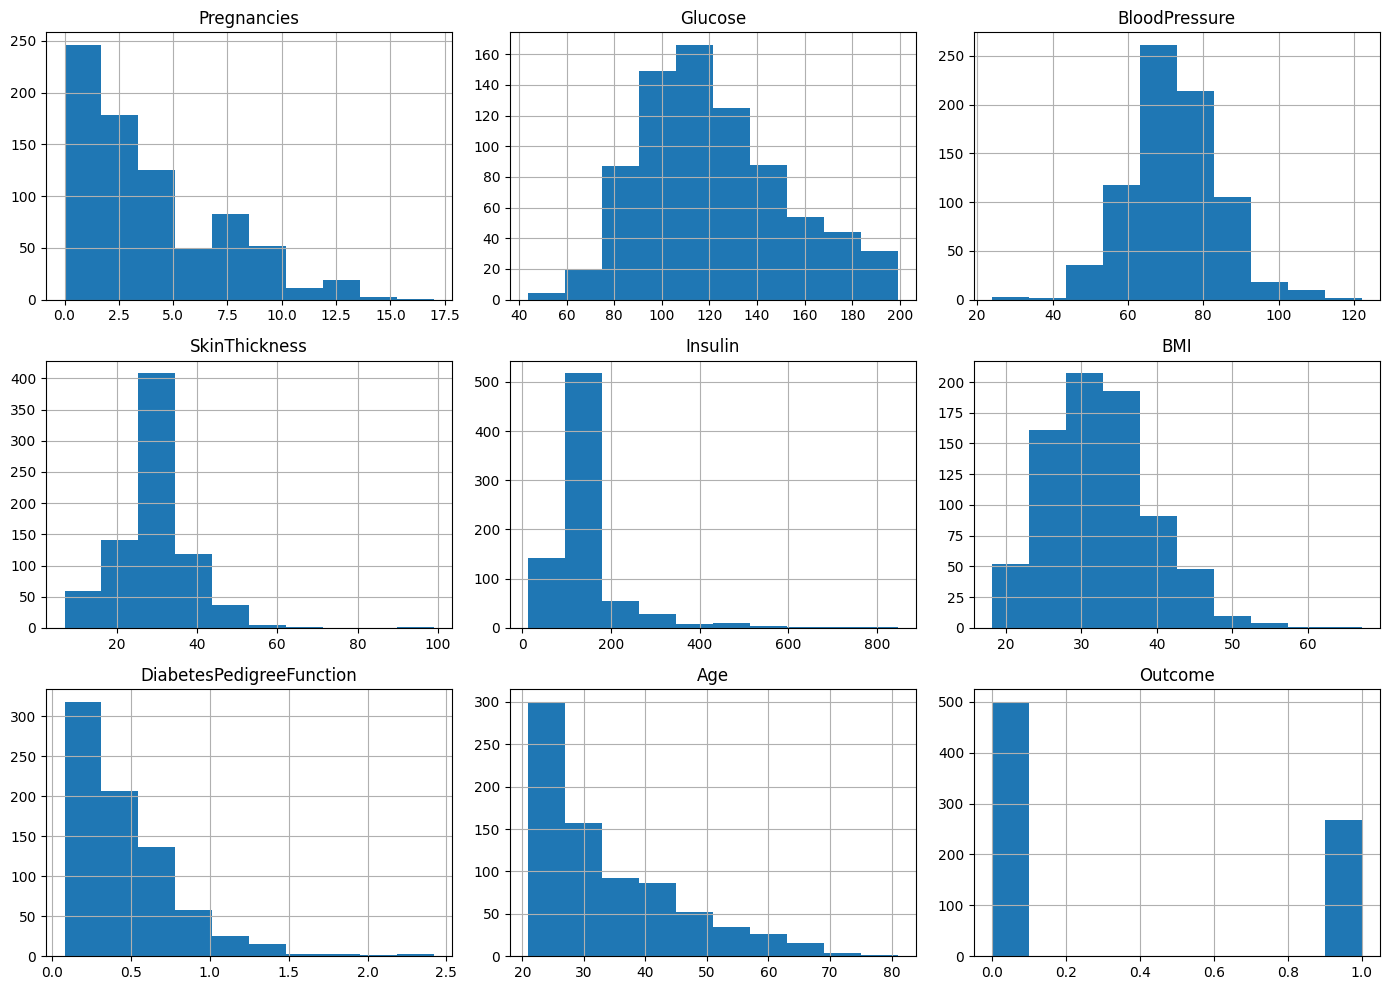

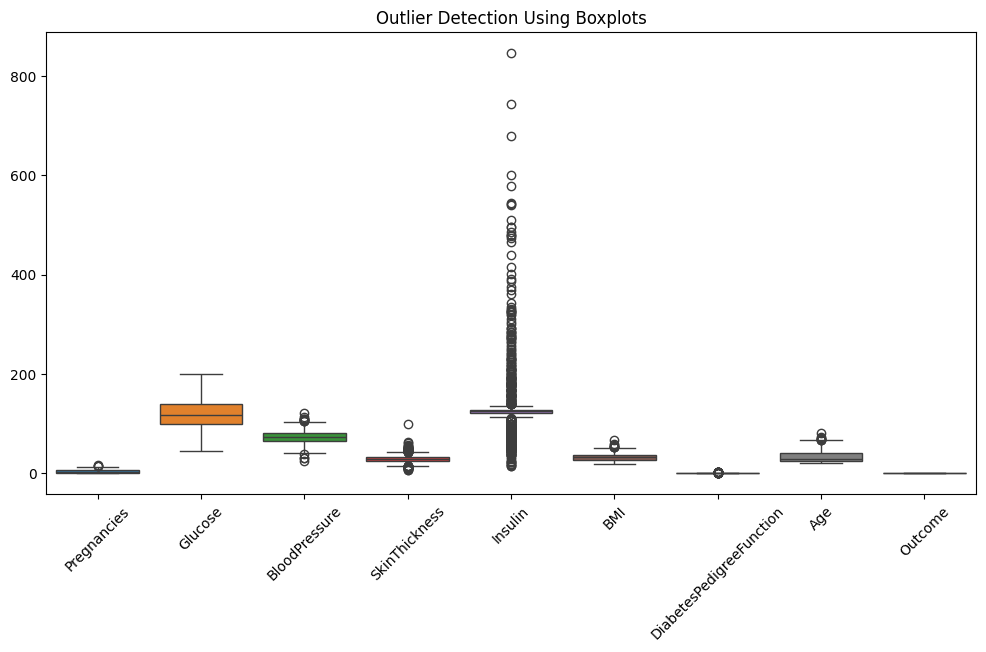

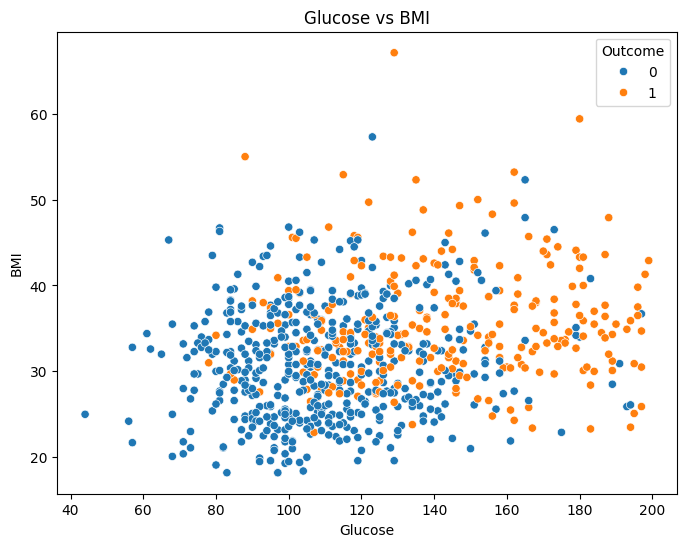

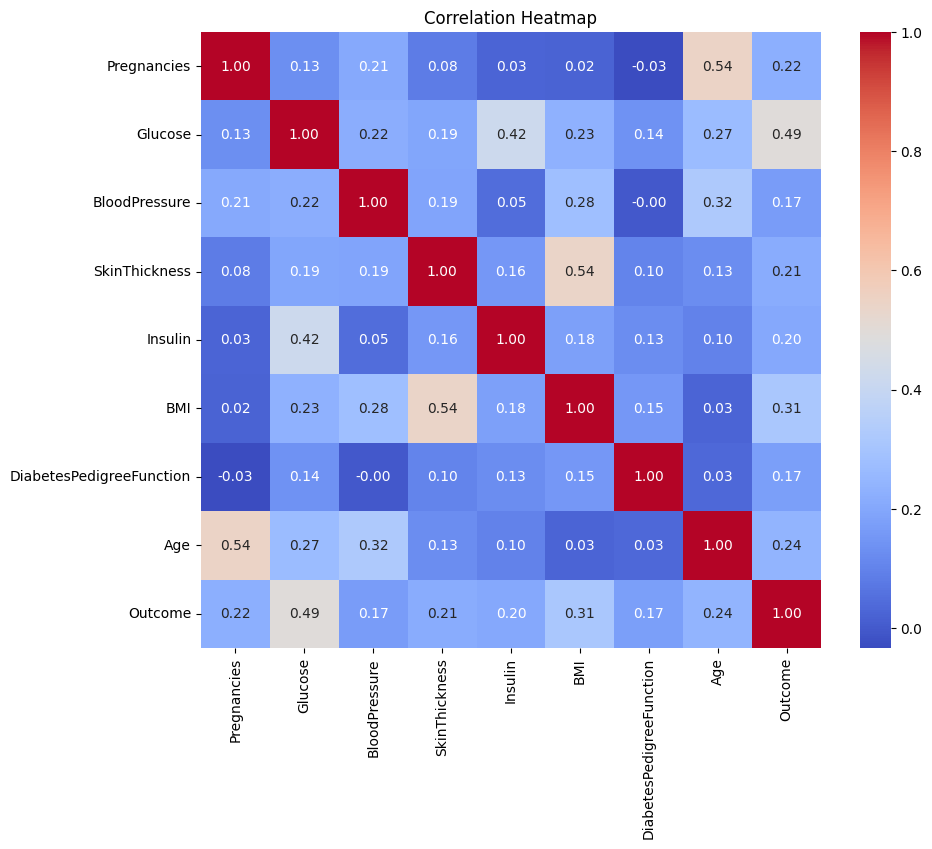

In [ ]:
print("\n")
print("=" * 60)
print("1. DATASET OVERVIEW")
print("=" * 60)

print("\nShape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

# ----------------------------------------------------------
# Missing Value Analysis
# ----------------------------------------------------------

print("\n")
print("=" * 60)
print("2. MISSING VALUE ANALYSIS")
print("=" * 60)

print("\nMissing Values:")
print(df.isnull().sum())

# In this dataset, zero values represent missing values
columns_with_zero_missing = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

for col in columns_with_zero_missing:
    df[col] = df[col].replace(0, np.nan)

print("\nMissing Values After Conversion:")
print(df.isnull().sum())

# Fill missing values with median
for col in columns_with_zero_missing:
    df[col].fillna(df[col].median(), inplace=True)

# ----------------------------------------------------------
# Statistical Summary
# ----------------------------------------------------------

print("\n")
print("=" * 60)
print("3. STATISTICAL SUMMARY")
print("=" * 60)

print(df.describe())

# ----------------------------------------------------------
# Create Output Folder
# ----------------------------------------------------------

os.makedirs("outputs", exist_ok=True)

# ----------------------------------------------------------
# Glucose Distribution
# ----------------------------------------------------------

plt.figure(figsize=(8,5))
sns.histplot(df['Glucose'], bins=30, kde=True)
plt.title("Distribution of Glucose Levels")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.savefig("outputs/glucose_distribution.png")
plt.show()

# ----------------------------------------------------------
# Histograms
# ----------------------------------------------------------

df.hist(figsize=(14,10))
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Boxplots (Outlier Detection)
# ----------------------------------------------------------

plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Outlier Detection Using Boxplots")
plt.show()

# ----------------------------------------------------------
# Scatter Plot
# ----------------------------------------------------------

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Glucose',
    y='BMI',
    hue='Outcome',
    data=df
)
plt.title("Glucose vs BMI")
plt.show()

# ----------------------------------------------------------
# Correlation Analysis
# ----------------------------------------------------------

plt.figure(figsize=(10,8))

corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.savefig("outputs/correlation_heatmap.png")
plt.show()

# 4. OUTLIER DETECTION (IQR METHOD)

In [ ]:

print("\n")
print("=" * 60)
print("4. OUTLIER DETECTION")
print("=" * 60)

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")



4. OUTLIER DETECTION
Pregnancies: 4 outliers
Glucose: 0 outliers
BloodPressure: 14 outliers
SkinThickness: 87 outliers
Insulin: 346 outliers
BMI: 8 outliers
DiabetesPedigreeFunction: 29 outliers
Age: 9 outliers
Outcome: 0 outliers


# 5. FEATURE ENGINEERING

In [ ]:
print("\n")
print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

X = df.drop("Outcome", axis=1)
y = df["Outcome"]



FEATURE ENGINEERING


# 6. TRAIN TEST SPLIT

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (614, 8)
Testing Shape: (154, 8)


 7. FEATURE SCALING

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 8. MODEL TRAINING

In [ ]:
models = {
    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Support Vector Machine":
        SVC(
            probability=True,
            kernel='rbf'
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )
}

results = []

print("\n")
print("=" * 60)
print("MODEL TRAINING & EVALUATION")
print("=" * 60)

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)

    probabilities = model.predict_proba(
        X_test_scaled
    )[:,1]

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

    print("\nClassification Report")
    print(
        classification_report(
            y_test,
            predictions
        )
    )





MODEL TRAINING & EVALUATION

Training Logistic Regression...

Classification Report
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


Training Support Vector Machine...

Classification Report
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154


Training Random Forest...

Classification Report
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.6

# 9. MODEL COMPARISON

In [ ]:


results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

print("\n")
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(results_df.sort_values(
    by="Accuracy",
    ascending=False
))



MODEL COMPARISON
                    Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
1  Support Vector Machine  0.740260   0.652174  0.555556  0.600000  0.796389
2           Random Forest  0.740260   0.652174  0.555556  0.600000  0.816111
0     Logistic Regression  0.707792   0.600000  0.500000  0.545455  0.812963


# 10. BEST MODEL

In [ ]:
best_model_name = results_df.sort_values(
    by="Recall",
    ascending=False
).iloc[0]["Model"]

print("\n")
print("=" * 60)
print(f"BEST MODEL BASED ON RECALL: {best_model_name}")
print("=" * 60)



BEST MODEL BASED ON RECALL: Support Vector Machine


# 11. RANDOM FOREST CONFUSION MATRIX

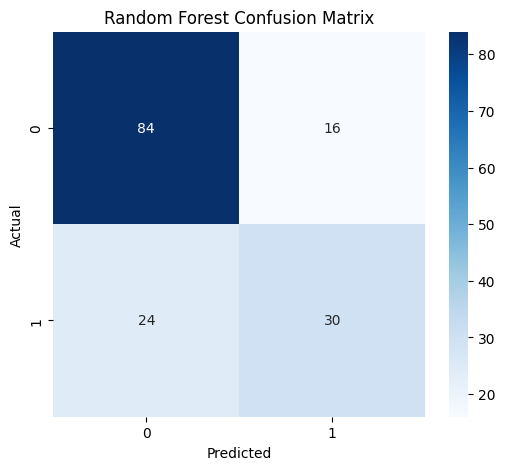

In [ ]:
rf_model = models["Random Forest"]

rf_predictions = rf_model.predict(
    X_test_scaled
)

cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "outputs/confusion_matrix_rf.png"
)

plt.show()


# 12. ROC CURVE COMPARISON

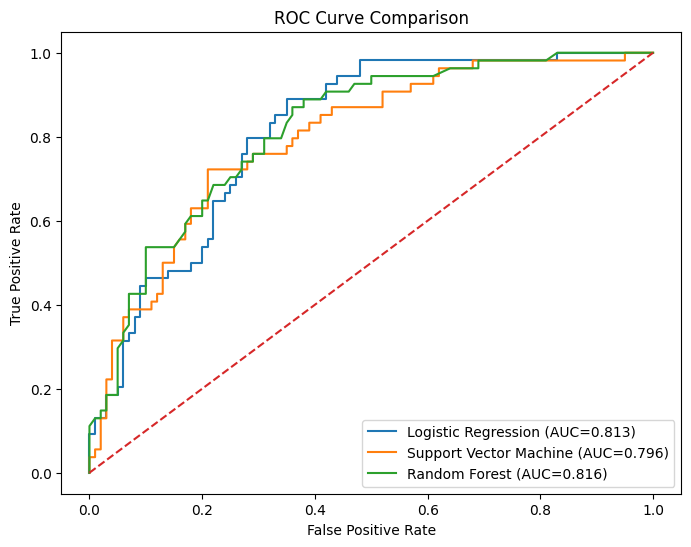

In [ ]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    probs = model.predict_proba(
        X_test_scaled
    )[:,1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probs
    )

    auc_score = roc_auc_score(
        y_test,
        probs
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_score:.3f})")

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


# 13. SAVE MODELS (DEPLOYMENT READY)

In [ ]:

os.makedirs(
    "saved_models",
    exist_ok=True
)

joblib.dump(
    scaler,
    "saved_models/scaler.pkl"
)

joblib.dump(
    models["Logistic Regression"],
    "saved_models/logistic_regression.pkl"
)

joblib.dump(
    models["Support Vector Machine"],
    "saved_models/svm.pkl"
)

joblib.dump(
    models["Random Forest"],
    "saved_models/random_forest.pkl"
)

print("\nModels Saved Successfully!")



Models Saved Successfully!


# 14. SAMPLE PREDICTION

In [ ]:
sample_patient = [[
    5,      # Pregnancies
    130,    # Glucose
    80,     # Blood Pressure
    25,     # Skin Thickness
    100,    # Insulin
    30.5,   # BMI
    0.5,    # Diabetes Pedigree Function
    45      # Age
]]

sample_scaled = scaler.transform(
    sample_patient
)

prediction = rf_model.predict(
    sample_scaled
)

print("\nPrediction Result:")

if prediction[0] == 1:
    print("Diabetic")
else:
    print("Non-Diabetic")

# ==========================================================
# END OF PROJECT



Prediction Result:
Diabetic
